In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import ks_2samp
patients = ['HUP64', 'HUP68', 'HUP70', 'HUP72','HUP78','HUP86','MAYO010','MAYO011','MAYO016','MAYO020']
main_pathname = 'c:/Users/yaoyu/Documents/Epilepsy_research/data_v2'
raw_data_path = 'c:/Users/yaoyu/Documents/Epilepsy_research/data'
output_path = 'C:/Users/yaoyu/Documents/Epilepsy_research/figures/'

# colors = ['#0084D9', "#D4D430", "#FF8800", '#800080'] #Interictal, Preictal, Ictal, Postictal 
segments = ['interictal', 'preictal', 'ictal', 'postictal']
# segment_colors = {
#     "Interictal": colors[0],
#     "Preictal": colors[1],
#     "Ictal": colors[2],
#     "Postictal": colors[3],
# }

In [2]:
# only including segments with good fit
alpha_dict = {}
eigen_dict = {}
for patient in patients: 
    path = os.path.join(main_pathname, patient, "valid_fos_blocks.npz")
    valid_fos_blocks = np.load(path)
    alpha_dict[patient] = {}
    eigen_dict[patient] = {}
    for seizure in range(1, 9):
        features_file = os.path.join(main_pathname, patient, f"fos_features_block_{seizure}.npz")
        if(os.path.exists(features_file)):
            features = np.load(features_file)
            for segment in segments:
                key = f"{segment}_r2_block_{seizure}"
                if key in valid_fos_blocks.files:
                    try: 
                        alpha_vals = features[f"{segment}_alpha"]
                        eigen_vals = features[f"{segment}_eigen"]
                        alpha_dict[patient].setdefault(segment, []).append(alpha_vals)
                        eigen_dict[patient].setdefault(segment, []).append(eigen_vals)
                    except Exception:
                        pass

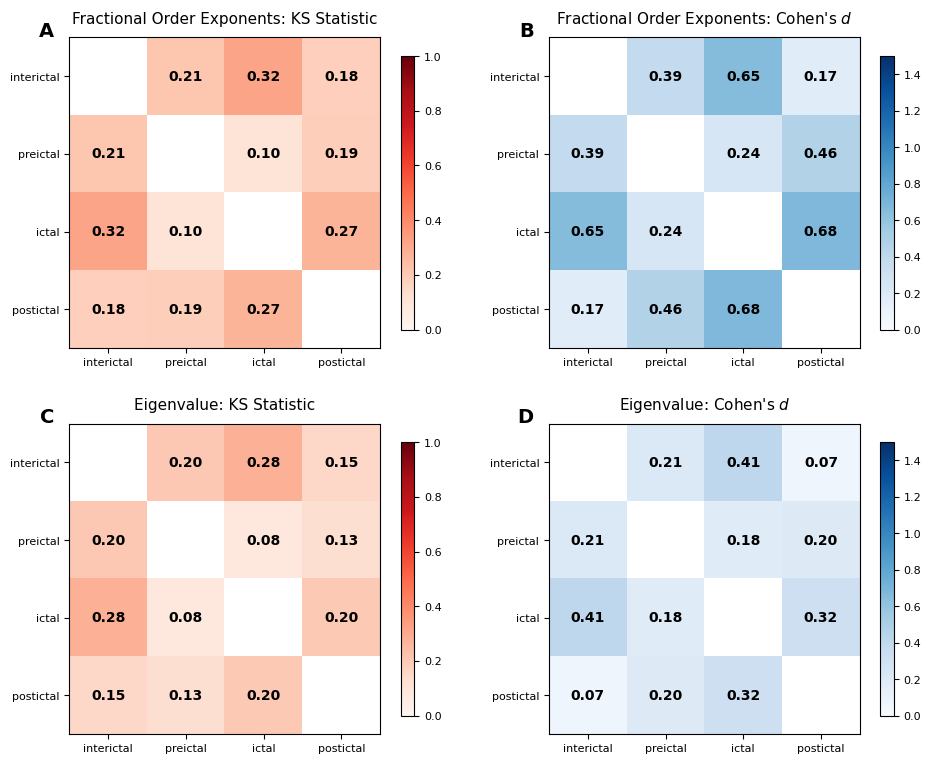

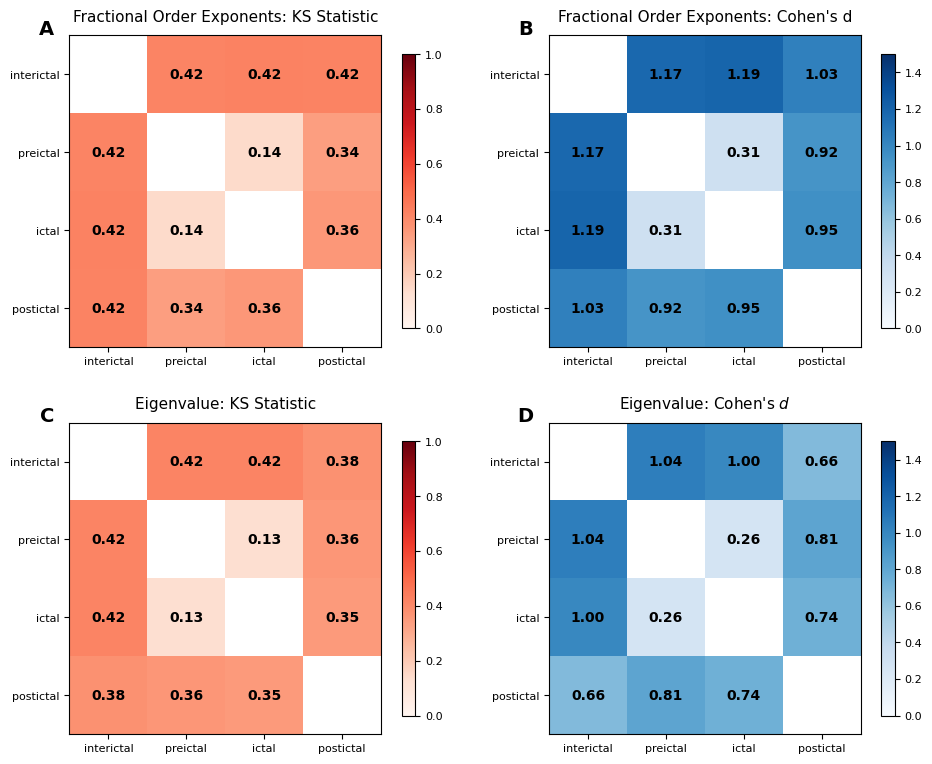

In [3]:
def cohens_d(x, y):
    x = np.real(x).astype(np.float64)
    y = np.real(y).astype(np.float64)

    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / dof)

    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else np.nan

def compute_segment_statistics_pooled(data_dict, patients, segments):
    """Compute KS and Cohen's D statistics for segment comparisons - POOLED across patients"""
    n_segments = len(segments)
    
    # Pool all data by segment across all patients
    pooled_data = {seg.lower(): [] for seg in segments}
    
    for patient in patients:
        for seg in segments:
            seg_lower = seg.lower()
            if seg_lower not in data_dict[patient]:
                continue
            # Flatten and append all valid blocks for this patient + segment
            pooled_data[seg_lower].extend([arr.flatten() for arr in data_dict[patient][seg_lower]])
    
    # Concatenate all arrays for each segment
    for seg in segments:
        seg_lower = seg.lower()
        if pooled_data[seg_lower]:
            pooled_data[seg_lower] = np.concatenate(pooled_data[seg_lower])
        else:
            pooled_data[seg_lower] = np.array([])
    
    # Compute pairwise statistics
    ks_matrix = np.full((n_segments, n_segments), np.nan)
    d_matrix = np.full((n_segments, n_segments), np.nan)
    
    for i, seg1 in enumerate(segments):
        for j, seg2 in enumerate(segments):
            seg1_lower = seg1.lower()
            seg2_lower = seg2.lower()
            
            data1 = pooled_data[seg1_lower]
            data2 = pooled_data[seg2_lower]
            
            if len(data1) == 0 or len(data2) == 0:
                continue
            
            ks_matrix[i, j] = ks_2samp(data1, data2).statistic
            d_matrix[i, j] = np.abs(cohens_d(data1, data2))
    
    return ks_matrix, d_matrix

def compute_segment_statistics_within_patient(data_dict, patients, segments):
    """Compute KS and Cohen's D statistics for segment comparisons - WITHIN patient then averaged"""
    n_segments = len(segments)
    ks_all_patients = []
    d_all_patients = []

    for patient in patients:
        # Initialize per-patient matrices
        ks_matrix = np.full((n_segments, n_segments), np.nan)
        d_matrix = np.full((n_segments, n_segments), np.nan)

        for i, seg1 in enumerate(segments):
            for j, seg2 in enumerate(segments):
                seg1_lower = seg1.lower()
                seg2_lower = seg2.lower()

                # Skip if the patient doesn't have these segments
                if seg1_lower not in data_dict[patient] or seg2_lower not in data_dict[patient]:
                    continue
                
                # Flatten all valid blocks for this patient + segment
                data1 = np.concatenate([arr.flatten() for arr in data_dict[patient][seg1_lower]])
                data2 = np.concatenate([arr.flatten() for arr in data_dict[patient][seg2_lower]])

                # If no valid data, skip
                if len(data1) == 0 or len(data2) == 0:
                    continue
                    
                ks_result = ks_2samp(data1, data2).statistic
                cohens = np.abs(cohens_d(data1, data2))
                
                # Compute KS and Cohen's D
                ks_matrix[i, j] = ks_result
                d_matrix[i, j] = cohens

        # Store this patient's results
        ks_all_patients.append(ks_matrix)
        d_all_patients.append(d_matrix)

    # Average across patients (ignore NaNs from missing blocks)
    ks_avg = np.nanmean(np.stack(ks_all_patients), axis=0)
    d_avg = np.nanmean(np.stack(d_all_patients), axis=0)
    
    return ks_avg, d_avg

def plot_heatmap(ax, data, segments, title, panel_label, is_cohens_d=False):
    """Plot a single heatmap with annotations and colorbar"""
    n_segments = len(segments)
    
    # Set colormap and vmax based on metric type
    if is_cohens_d:
        cmap = 'Blues'
        vmax = 1.5
    else:
        cmap = 'Reds' 
        vmax = 1.0
    
    # Create heatmap
    masked_data = np.ma.masked_invalid(data)
    im = ax.imshow(masked_data, cmap=cmap, vmin=0, vmax=vmax, aspect='equal')
    
    # Set ticks and labels
    ax.set_xticks(range(n_segments))
    ax.set_yticks(range(n_segments))
    ax.set_xticklabels(segments, rotation=0, fontsize=8)
    ax.set_yticklabels(segments, fontsize=8)
    ax.set_title(title, fontsize=11, pad=10)
    
    # Add panel label
    ax.text(-0.05, 1.05, panel_label, transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='right')
    
    # Add text annotations
    for i in range(n_segments):
        for j in range(n_segments):
            if not np.isnan(data[i, j]):
                ax.text(j, i, f'{data[i, j]:.2f}', 
                       ha='center', va='center', fontweight='bold', color='black')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.88, aspect=20)
    cbar.ax.tick_params(labelsize=8)
    
    return im

n_segments = len(segments)

# Compute POOLED statistics
alpha_ks_pooled, alpha_d_pooled = compute_segment_statistics_pooled(alpha_dict, patients, segments)
eigen_ks_pooled, eigen_d_pooled = compute_segment_statistics_pooled(eigen_dict, patients, segments)

# Compute WITHIN-PATIENT statistics
alpha_ks_within, alpha_d_within = compute_segment_statistics_within_patient(alpha_dict, patients, segments)
eigen_ks_within, eigen_d_within = compute_segment_statistics_within_patient(eigen_dict, patients, segments)

# Create POOLED 
# Mask the diagonal for visualization
np.fill_diagonal(alpha_ks_pooled, np.nan)
np.fill_diagonal(alpha_d_pooled, np.nan)
np.fill_diagonal(eigen_ks_pooled, np.nan)
np.fill_diagonal(eigen_d_pooled, np.nan)

fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8))
plot_heatmap(axes1[0, 0], alpha_ks_pooled, segments, r"Fractional Order Exponents: KS Statistic", 'A', is_cohens_d=False)
plot_heatmap(axes1[0, 1], alpha_d_pooled, segments, r"Fractional Order Exponents: Cohen's $d$", 'B', is_cohens_d=True)
plot_heatmap(axes1[1, 0], eigen_ks_pooled, segments, 'Eigenvalue: KS Statistic', 'C', is_cohens_d=False)
plot_heatmap(axes1[1, 1], eigen_d_pooled, segments, r"Eigenvalue: Cohen's $d$", 'D', is_cohens_d=True)
plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_path, f"pairwise_heatmap_pooled.pdf"), bbox_inches='tight')
plt.show()
plt.close()

# Create WITHIN-PATIENT figure
# Mask the diagonal for visualization
np.fill_diagonal(alpha_ks_within, np.nan)
np.fill_diagonal(alpha_d_within, np.nan)
np.fill_diagonal(eigen_ks_within, np.nan)
np.fill_diagonal(eigen_d_within, np.nan)

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
plot_heatmap(axes2[0, 0], alpha_ks_within, segments, r"Fractional Order Exponents: KS Statistic", 'A', is_cohens_d=False)
plot_heatmap(axes2[0, 1], alpha_d_within, segments, r"Fractional Order Exponents: Cohen's d", 'B', is_cohens_d=True)
plot_heatmap(axes2[1, 0], eigen_ks_within, segments, 'Eigenvalue: KS Statistic', 'C', is_cohens_d=False)
plot_heatmap(axes2[1, 1], eigen_d_within, segments, r"Eigenvalue: Cohen's $d$", 'D', is_cohens_d=True)
plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(output_path, f"pairwise_heatmap_within_patient.pdf"), bbox_inches='tight')
plt.show()
plt.close()

In [41]:
def cohens_d(x, y):
    x = np.real(x).astype(np.float64)
    y = np.real(y).astype(np.float64)

    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / dof)

    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else np.nan

def hierarchical_bootstrap_ks(data_dict, patients, seg1, seg2, n_bootstrap=5000):
    """
    Hierarchical bootstrap for KS statistic
    Returns: (ks_observed, p_value) or (np.nan, np.nan) if insufficient data
    """
    # Get valid patients - just check if they have both segments
    valid_patients = [p for p in patients if seg1 in data_dict[p] and seg2 in data_dict[p]]
      
    # Check if we have enough patients
    if len(valid_patients) < 2:
        print(f"    FAILED: Only {len(valid_patients)} valid patients")
        return np.nan, np.nan
    
    n_patients = len(valid_patients)
    
    # Compute observed KS statistic
    seg1_data = []
    seg2_data = []
    for patient in valid_patients:
        seg1_data.append(np.concatenate([arr.flatten() for arr in data_dict[patient][seg1]]))
        seg2_data.append(np.concatenate([arr.flatten() for arr in data_dict[patient][seg2]]))
 
    seg1_pooled = np.concatenate(seg1_data)
    seg2_pooled = np.concatenate(seg2_data)        
    ks_observed = ks_2samp(seg1_pooled, seg2_pooled).statistic    
    # Bootstrap
    ks_bootstrap = []
    for b in range(n_bootstrap):
        bootstrap_patients = np.random.choice(valid_patients, size=n_patients, replace=True)
        
        seg1_boot = []
        seg2_boot = []
        
        for patient in bootstrap_patients:
            seg1_seizures = data_dict[patient][seg1]
            seg2_seizures = data_dict[patient][seg2]
            
            n_seizures_seg1 = len(seg1_seizures)
            n_seizures_seg2 = len(seg2_seizures)
            
            boot_idx_seg1 = np.random.choice(n_seizures_seg1, size=n_seizures_seg1, replace=True)
            boot_idx_seg2 = np.random.choice(n_seizures_seg2, size=n_seizures_seg2, replace=True)
            
            seg1_patient_boot = np.concatenate([seg1_seizures[i].flatten() for i in boot_idx_seg1])
            seg2_patient_boot = np.concatenate([seg2_seizures[i].flatten() for i in boot_idx_seg2])
            
            seg1_boot.append(seg1_patient_boot)
            seg2_boot.append(seg2_patient_boot)
        
        seg1_boot_pooled = np.concatenate(seg1_boot)
        seg2_boot_pooled = np.concatenate(seg2_boot)
        ks_b = ks_2samp(seg1_boot_pooled, seg2_boot_pooled).statistic
        ks_bootstrap.append(ks_b)
    
    ks_bootstrap = np.array(ks_bootstrap)
    p_value = (np.sum(ks_bootstrap >= ks_observed) + 1) / (n_bootstrap + 1)    
    
    return ks_observed, p_value

Computing Alpha statistics...
  interictal vs preictal... d=1.17, p=0.5741
  interictal vs ictal... d=1.28, p=0.5489
  interictal vs postictal... d=1.03, p=0.5489
  preictal vs ictal... d=0.28, p=0.6597
  preictal vs postictal... d=0.92, p=0.5209
  ictal vs postictal... d=1.00, p=0.4991

Computing Eigenvalue statistics...
  interictal vs preictal... d=1.04, p=0.5601
  interictal vs ictal... d=1.09, p=0.5421
  interictal vs postictal... d=0.66, p=0.6179
  preictal vs ictal... d=0.25, p=0.7421
  preictal vs postictal... d=0.81, p=0.6999
  ictal vs postictal... d=0.79, p=0.5793


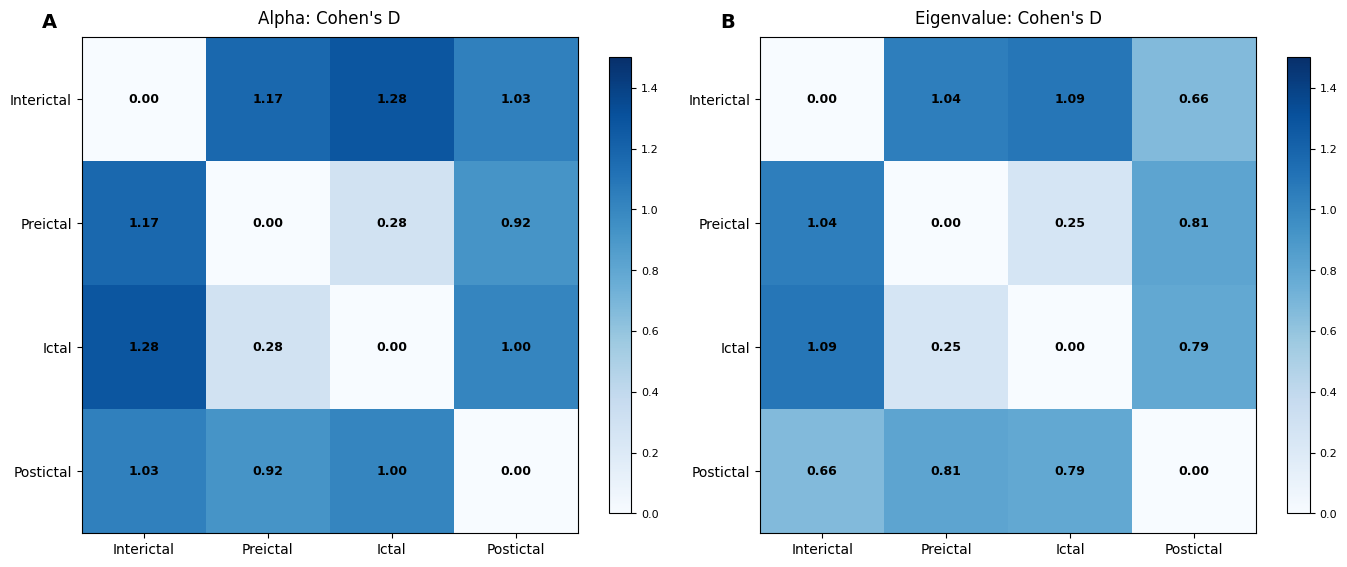

In [42]:
n_segments = len(segments)
np.random.seed(42)
# Alpha value comparison 
cohens_d_alpha = np.full((n_segments, n_segments), np.nan)
ks_alpha = np.full((n_segments, n_segments), np.nan)
p_values_alpha = np.full((n_segments, n_segments), np.nan)

print("Computing Alpha statistics...")
for i, seg1 in enumerate(segments):
    for j, seg2 in enumerate(segments):
        if i == j:
            cohens_d_alpha[i, j] = 0
            ks_alpha[i, j] = 0
            p_values_alpha[i, j] = 1.0
            continue
        
        if i > j:
            cohens_d_alpha[i, j] = cohens_d_alpha[j, i]
            ks_alpha[i, j] = ks_alpha[j, i]
            p_values_alpha[i, j] = p_values_alpha[j, i]
            continue

        print(f"  {seg1} vs {seg2}...", end=" ")
        
        # Cohen's d (per-patient average)
        cohens_list = []
        for patient in patients:
            if seg1 in alpha_dict[patient] and seg2 in alpha_dict[patient]:
                
                data1 = np.concatenate([arr.flatten() for arr in alpha_dict[patient][seg1]])
                data2 = np.concatenate([arr.flatten() for arr in alpha_dict[patient][seg2]])
                
                if len(data1) > 0 and len(data2) > 0:
                    d = np.abs(cohens_d(data1, data2))
                    if not np.isnan(d):
                        cohens_list.append(d)
        
        cohens_d_alpha[i, j] = np.mean(cohens_list) if cohens_list else np.nan
        
        # Hierarchical bootstrap
        ks_obs, p_val = hierarchical_bootstrap_ks(alpha_dict, patients, seg1, seg2, n_bootstrap=5000)
        ks_alpha[i, j] = ks_obs
        p_values_alpha[i, j] = p_val
        
        print(f"d={cohens_d_alpha[i, j]:.2f}, p={p_val:.4f}")

# Eigenvalue comparison

cohens_d_eigen = np.full((n_segments, n_segments), np.nan)
ks_eigen = np.full((n_segments, n_segments), np.nan)
p_values_eigen = np.full((n_segments, n_segments), np.nan)

print("\nComputing Eigenvalue statistics...")
for i, seg1 in enumerate(segments):
    for j, seg2 in enumerate(segments):
        if i == j:
            cohens_d_eigen[i, j] = 0
            ks_eigen[i, j] = 0
            p_values_eigen[i, j] = 1.0
            continue
        
        if i > j:
            cohens_d_eigen[i, j] = cohens_d_eigen[j, i]
            ks_eigen[i, j] = ks_eigen[j, i]
            p_values_eigen[i, j] = p_values_eigen[j, i]
            continue

        print(f"  {seg1} vs {seg2}...", end=" ")
        
        # Cohen's d
        cohens_list = []
        for patient in patients:
            if seg1 in eigen_dict[patient] and seg2 in eigen_dict[patient]:
                if patient == "HUP70" and ("ictal" in [seg1, seg2]):
                    continue
                
                data1 = np.concatenate([arr.flatten() for arr in eigen_dict[patient][seg1]])
                data2 = np.concatenate([arr.flatten() for arr in eigen_dict[patient][seg2]])
                
                if len(data1) > 0 and len(data2) > 0:
                    d = np.abs(cohens_d(data1, data2))
                    if not np.isnan(d):
                        cohens_list.append(d)
        
        cohens_d_eigen[i, j] = np.mean(cohens_list) if cohens_list else np.nan
        
        # Hierarchical bootstrap
        ks_obs, p_val = hierarchical_bootstrap_ks(eigen_dict, patients, seg1, seg2, n_bootstrap=5000)
        ks_eigen[i, j] = ks_obs
        p_values_eigen[i, j] = p_val
        
        print(f"d={cohens_d_eigen[i, j]:.2f}, p={p_val:.4f}")

# Heatmaps

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
segments_cap = ['Interictal', 'Preictal', 'Ictal', 'Postictal']

for ax_idx, (ax, data, p_vals, title, panel) in enumerate([
    (axes[0], cohens_d_alpha, p_values_alpha, "Alpha: Cohen's D", 'A'),
    (axes[1], cohens_d_eigen, p_values_eigen, "Eigenvalue: Cohen's D", 'B')
]):
    # Plot heatmap
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=1.5, aspect='equal')
    
    # Labels
    ax.set_xticks(range(n_segments))
    ax.set_yticks(range(n_segments))
    ax.set_xticklabels(segments_cap, rotation=0, fontsize=10)
    ax.set_yticklabels(segments_cap, fontsize=10)
    ax.set_title(title, fontsize=12, pad=10)
    
    # Panel label
    ax.text(-0.05, 1.05, panel, transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='top', ha='right')
    
    # Annotations with significance markers
    for i in range(n_segments):
        for j in range(n_segments):
            if not np.isnan(data[i, j]):
                p = p_vals[i, j]
                if p < 0.001:
                    sig = '***'
                elif p < 0.01:
                    sig = '**'
                elif p < 0.05:
                    sig = '*'
                else:
                    sig = ''
                
                text = f'{data[i, j]:.2f}{sig}'
                ax.text(j, i, text, ha='center', va='center', 
                       fontweight='bold', color='black', fontsize=9) 
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.80, aspect=20)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"hierarchical_bootstrap_results.pdf"), bbox_inches ='tight')
plt.show()


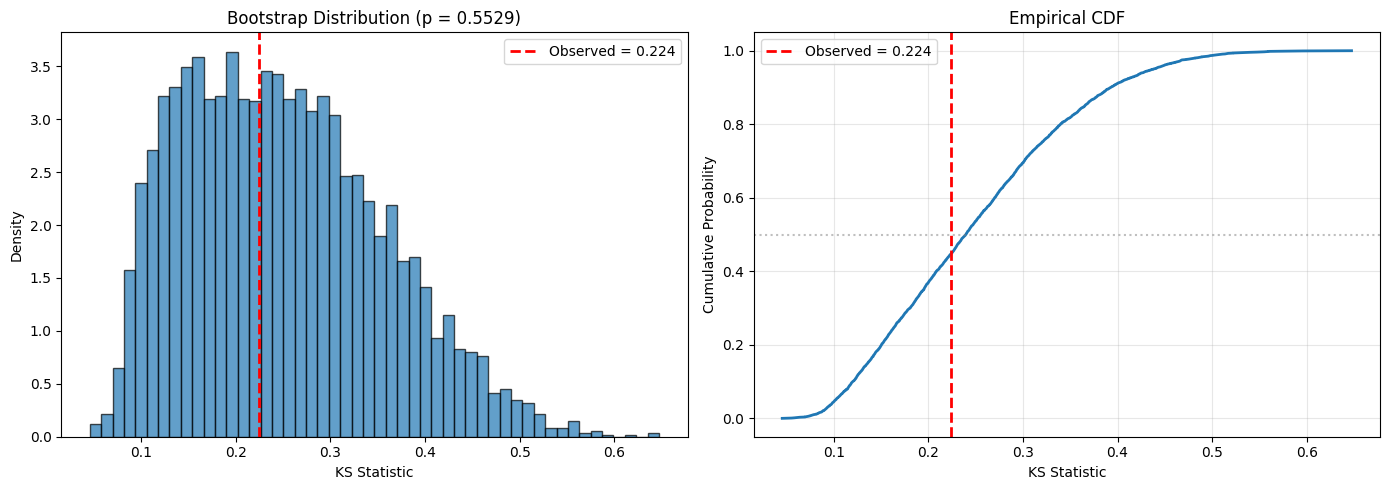

Observed KS: 0.224
Bootstrap KS - Mean: 0.249, Std: 0.104
Bootstrap KS - Range: [0.045, 0.647]
Observed percentile in bootstrap: 44.7%
P-value: 0.5529


In [ ]:
# testing
def hierarchical_bootstrap_ks_debug(data_dict, patients, seg1, seg2, n_bootstrap=5000):
    """Returns ks_observed, p_value, ks_bootstrap array"""
    valid_patients = [p for p in patients if seg1 in data_dict[p] and seg2 in data_dict[p]]
    
    if len(valid_patients) < 2:
        return np.nan, np.nan, None
    
    n_patients = len(valid_patients)
    
    # Compute observed
    seg1_data = []
    seg2_data = []
    for patient in valid_patients:
        seg1_data.append(np.concatenate([arr.flatten() for arr in data_dict[patient][seg1]]))
        seg2_data.append(np.concatenate([arr.flatten() for arr in data_dict[patient][seg2]]))
    
    seg1_pooled = np.concatenate(seg1_data)
    seg2_pooled = np.concatenate(seg2_data)
    ks_observed = ks_2samp(seg1_pooled, seg2_pooled).statistic
    
    # Bootstrap
    ks_bootstrap = []
    for b in range(n_bootstrap):
        bootstrap_patients = np.random.choice(valid_patients, size=n_patients, replace=True)
        
        seg1_boot = []
        seg2_boot = []
        
        for patient in bootstrap_patients:
            seg1_seizures = data_dict[patient][seg1]
            seg2_seizures = data_dict[patient][seg2]
            
            n_seizures_seg1 = len(seg1_seizures)
            n_seizures_seg2 = len(seg2_seizures)
            
            boot_idx_seg1 = np.random.choice(n_seizures_seg1, size=n_seizures_seg1, replace=True)
            boot_idx_seg2 = np.random.choice(n_seizures_seg2, size=n_seizures_seg2, replace=True)
            
            seg1_patient_boot = np.concatenate([seg1_seizures[i].flatten() for i in boot_idx_seg1])
            seg2_patient_boot = np.concatenate([seg2_seizures[i].flatten() for i in boot_idx_seg2])
            
            seg1_boot.append(seg1_patient_boot)
            seg2_boot.append(seg2_patient_boot)
        
        seg1_boot_pooled = np.concatenate(seg1_boot)
        seg2_boot_pooled = np.concatenate(seg2_boot)
        ks_b = ks_2samp(seg1_boot_pooled, seg2_boot_pooled).statistic
        ks_bootstrap.append(ks_b)
    
    ks_bootstrap = np.array(ks_bootstrap)
    p_value = (np.sum(ks_bootstrap >= ks_observed) + 1) / (n_bootstrap + 1)
    
    return ks_observed, p_value, ks_bootstrap

ks_obs, p_val, ks_boot = hierarchical_bootstrap_ks_debug(alpha_dict, patients, 'interictal', 'ictal', n_bootstrap=5000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ks_boot, bins=50, alpha=0.7, edgecolor='black', density=True)
axes[0].axvline(ks_obs, color='red', linestyle='--', linewidth=2, label=f'Observed = {ks_obs:.3f}')
axes[0].set_xlabel('KS Statistic')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Bootstrap Distribution (p = {p_val:.4f})')
axes[0].legend()

# ECDF to see where observed falls
sorted_boot = np.sort(ks_boot)
ecdf = np.arange(1, len(sorted_boot) + 1) / len(sorted_boot)
axes[1].plot(sorted_boot, ecdf, linewidth=2)
axes[1].axvline(ks_obs, color='red', linestyle='--', linewidth=2, label=f'Observed = {ks_obs:.3f}')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('KS Statistic')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Empirical CDF')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Observed KS: {ks_obs:.3f}")
print(f"Bootstrap KS - Mean: {ks_boot.mean():.3f}, Std: {ks_boot.std():.3f}")
print(f"Bootstrap KS - Range: [{ks_boot.min():.3f}, {ks_boot.max():.3f}]")
print(f"Observed percentile in bootstrap: {(ks_boot < ks_obs).sum() / len(ks_boot) * 100:.1f}%")
print(f"P-value: {p_val:.4f}")